In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve, factorized
from scipy.linalg import null_space
from scipy.interpolate import RegularGridInterpolator, interp1d, griddata, LinearNDInterpolator
import ipywidgets as widgets
from skfem import *
from skfem.helpers import dot, grad
from skfem.visuals.matplotlib import plot as fem_plot
from skfem.visuals.matplotlib import draw
from mpl_toolkits.axes_grid1 import make_axes_locatable
import meshpy.triangle as triangle
from scipy.integrate import solve_ivp, cumulative_trapezoid
import time
import pandas as pd
from scipy.stats import gaussian_kde
from shapely.geometry import Point, Polygon
from matplotlib.figure import Figure
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from solve_nivp import solve_nivp
from solve_nivp.projections import Projection
import scipy.sparse as sp

lwidth = 2
fname = 'Latin Modern Roman'
fsize = 20
import random
random.seed(20)

day=24 #hr
month=30.4375*day #hr
year=365.25*day #hr

## Load geometry and wells, simplify and build mesh

In [51]:
chy=4.4e-2  #Best
beta=1.9e-3  #Best
Gsat=0.30 #[-]
beta=beta*Gsat
mu = 0.5 # coefficient of friction [-]
a = 0.003 # [-]
sigma = 16.67 # [MPa]
dtau0 = 1e-7 # [MPa/h]
ta = a*sigma/dtau0 # [h]
γ1=mu/(dtau0*ta)
γ2=1/ta
Rsm=1e-2/year
R0=Rsm

In [70]:
def equidistant_3_points(d):
    """
    Three points in R^2 with pairwise distance d,
    centered around (0, 0).
    """
    R = d / np.sqrt(3)  # distance from each point to center

    angles = np.array([0, 2*np.pi/3, 4*np.pi/3])
    points = R * np.column_stack((np.cos(angles), np.sin(angles)))

    return points
    
WLpoints = equidistant_3_points(d=.5)
ctrl_wells=[0,1]#np.arange(len(WLpoints))
temp=np.eye(len(WLpoints))
B_ctrl=temp[:,ctrl_wells]
sttc_wells=np.setdiff1d(np.arange(len(WLpoints)), ctrl_wells)
B_sttc=temp[:,sttc_wells]

In [71]:
xmin, xmax = -2., 2.
ymin, ymax = -2., 2.
dz = .2

def get_mesh(mesh_elements):
    # Create quadrilateral mesh
    m_quad = MeshQuad1.init_tensor(np.linspace(xmin, xmax, mesh_elements + 1), np.linspace(ymin, ymax, mesh_elements + 1))
    points = m_quad.p.T
    quads = m_quad.t.T 
    
    # New points: Add one center point for each quad
    num_original_points = points.shape[0]
    center_points = np.array([points[q].mean(axis=0) for q in quads])  # Compute the center of each quad
    points = np.vstack([points, center_points])  # Append new points
    
    # New triangles (each quad becomes 4 triangles)
    new_triangles = []
    center_point_index = num_original_points
    for i, quad in enumerate(quads):
        a, b, c, d = quad  # Quad node indices
        o = center_point_index + i  # Center point index
    
        new_triangles.append([a, b, o])
        new_triangles.append([b, c, o])
        new_triangles.append([c, d, o])
        new_triangles.append([d, a, o])
    
    triangles = np.array(new_triangles)
    m = MeshTri(points.T, triangles.T)

    points = m.p.T  # Get the coordinates of the mesh points
    triangles = m.t.T  # Get the mesh element connectivity
    return m, points, triangles

mesh_elements = 11
element = ElementTriP1()
m, points, triangles = get_mesh(mesh_elements)

## Form the FE problem

In [72]:
import numpy as np
from scipy.sparse import csr_matrix

from skfem import (
    Basis, InteriorFacetBasis, Functional, BilinearForm, solve
)
from skfem.helpers import dot, grad
from skfem.element import ElementTriP1, ElementTriP0

# adaptive marking helper (API location may vary slightly across skfem versions)
try:
    from skfem.utils import adaptive_theta
except Exception:  # fallback
    from skfem import adaptive_theta

class Diffusion:

    def __init__(self, mesh, chy, ctrl_pts, sttc_pts, beta, element=None, dz=None, Dirichlet=False):
        """
        mesh : skfem Mesh (e.g., MeshTri)
        chy  : float OR callable (x, y) -> chy values (vectorized)
        element : skfem element for u, default ElementTriP1()
        """
        self.m0 = mesh
        self.chy = chy
        self.e = element if element is not None else ElementTriP1()
        self.ctrl_pts = ctrl_pts 
        self.sttc_pts = sttc_pts
        self.beta = beta 
        self.dz = 1.0 if dz is None else dz
        
        self.assemble_stiffness(m)
        self.assemble_point_sources_rhs(m, self.ctrl_pts, self.sttc_pts, self.beta, self.dz)
        self.assemble_mass(m)

        self.Dirichlet = Dirichlet
        if self.Dirichlet:
            b = self.Bc.dot(np.ones(self.Bc.shape[1]))+self.Bs.dot(np.ones(self.Bs.shape[1]))
            self.Ad, b = enforce(self.Ad, b, D=m.boundary_nodes()) 
            
    # -------------------------
    # Coefficient evaluation
    # -------------------------
    def _chy_fun(self, x, y):
        """Vectorized coefficient evaluation at points (x, y)."""
        if np.isscalar(self.chy):
            return np.asarray(self.chy) * np.ones_like(x, dtype=float)
        # callable: allow signature chy((x,y)) or chy(x,y)
        try:
            val = self.chy((x, y))
        except TypeError:
            val = self.chy(x, y)
        return np.asarray(val, dtype=float)

    def _project_chy_P0(self, m):
        """
        Represent chy as P0 (piecewise constant per element) DOFs, good for facet-side evaluation.
        """
        basis0 = Basis(m, ElementTriP0())

        def chy_xy(x):
            # x is shape (2, npts) for skfem
            return self._chy_fun(x[0], x[1])

        return basis0.project(chy_xy)  # (n_elements,)

    # -------------------------
    # Assembly
    # -------------------------
    def assemble_stiffness(self, m):
        """Assemble Ad = ∫ chy ∇u·∇v."""
        basis = Basis(m, self.e)

        @BilinearForm
        def a(u, v, w):
            x, y = w.x[0], w.x[1]
            chy_val = self._chy_fun(x, y)
            return chy_val * dot(grad(u), grad(v))

        self.Ad = a.assemble(basis)
        return self.Ad

    def assemble_mass(self, m):
        basis = Basis(m, self.e)
        
        @BilinearForm
        def trans_term(u, v, w):
            return u*v

        self.Md = asm(trans_term, basis)
        
    def assemble_point_sources_rhs(self, m, ctrl_pts, sttc_pts, beta, dz=None):
        basis = Basis(m, self.e)
        
        csources = ctrl_pts
        Bc=np.zeros((basis.N,len(csources)))
        for i in range(len(csources)):
            Bc[:,i] = basis.point_source(csources[i])/beta/dz
        self.Bc = csr_matrix(Bc)
        
        ssources = sttc_pts
        Bs=np.zeros((basis.N,len(ssources)))
        for i in range(len(ssources)):
            Bs[:,i] = basis.point_source(ssources[i])/beta/dz
        self.Bs = csr_matrix(Bs)
    
    # -------------------------
    # Estimator: flux jump
    # -------------------------
    def flux_jump_estimator(self, m, u):
        """
        Compute elementwise estimator eta(K) from interior facet flux jumps.

        Returns:
            eta : array of shape (n_elements,)
        """
        # facet bases for u (P1)
        fbasis_u = [InteriorFacetBasis(m, self.e, side=i) for i in (0, 1)]

        # represent chy as P0 per element, then evaluate on each facet side
        chy0 = self._project_chy_P0(m)
        fbasis_chy = [InteriorFacetBasis(m, ElementTriP0(), side=i) for i in (0, 1)]

        w = {
            "u1": fbasis_u[0].interpolate(u),
            "u2": fbasis_u[1].interpolate(u),
            "chy1": fbasis_chy[0].interpolate(chy0),
            "chy2": fbasis_chy[1].interpolate(chy0),
        }

        @Functional
        def edge_jump(w):
            h = w.h
            n = w.n
            dw1 = grad(w["u1"])
            dw2 = grad(w["u2"])
            chy1 = w["chy1"]
            chy2 = w["chy2"]

            # normal flux on each side
            flux1 = chy1 * (dw1[0] * n[0] + dw1[1] * n[1])
            flux2 = chy2 * (dw2[0] * n[0] + dw2[1] * n[1])

            return h * (flux1 - flux2) ** 2

        eta_F = edge_jump.elemental(fbasis_u[0], **w)  # facet contributions

        # Scatter facet contributions to elements (like your previous pattern)
        tmp = np.zeros(m.facets.shape[1], dtype=float)
        np.add.at(tmp, fbasis_u[0].find, eta_F)  # collect for global facet ids

        # map facets to triangles via t2f and sum the 3 facet contributions
        eta_E = np.sum(0.5 * tmp[m.t2f], axis=0)  # (n_elements,)
        boundary_nodes = set(m.boundary_nodes())
        is_boundary_triangle = np.any(np.isin(m.t, list(boundary_nodes)), axis=0)
        eta_E[is_boundary_triangle] = 0.0
        return eta_E

    # -------------------------
    # Main driver
    # -------------------------
    def refine(
        self,
        refined_steps,
        Qtest,
        theta=0.5,
        smooth_each_step=True,
        return_solutions=False,
    ):
        """
        Parameters
        ----------
        refined_steps : int
            number of refinement rounds.
        theta : float
            marking fraction for adaptive_theta.
        smooth_each_step : bool
            apply .smoothed() after each refinement.
        return_solutions : bool
            if True, returns list of (mesh, u, eta)

        Returns
        -------
        m : refined mesh
        (optionally) history : list of dicts
        """

        m = self.m0
        history = []

        for k in range(refined_steps, 0, -1):
            # assemble and solve
            self.assemble_stiffness(m)
            self.assemble_point_sources_rhs(m, self.ctrl_pts, self.sttc_pts, self.beta, self.dz)
            self.assemble_mass(m)
            b = self.Bc.dot(np.ones(self.Bc.shape[1]))+self.Bs.dot(np.ones(self.Bs.shape[1]))
            if self.Dirichlet:
                self.Ad, b = enforce(self.Ad, b, D=m.boundary_nodes()) 
            u = solve(self.Ad, Qtest*b)

            # estimate
            eta = self.flux_jump_estimator(m, u)
            tol = 1e-14 * np.max(eta) if np.max(eta) > 0 else 0.0
            eta = np.where(eta < tol, 0.0, eta)
            
            if return_solutions:
                history.append({"mesh": m, "u": u, "eta": eta})

            # refine except last
            if k > 1:
                marked = adaptive_theta(eta, theta=theta)
                m = m.refined(marked)
                if smooth_each_step:
                    m = m.smoothed()
                    
        if return_solutions:
            return m, history
        return m

In [73]:
from scipy.ndimage import gaussian_filter

# ---- build Tier A multiplier field on the grid ----
rng = np.random.default_rng(20)
resX, resY = 100, 100

m_min, m_max = 0.42, 1.39
a, b = np.log10(m_min), np.log10(m_max)

log10_factor = rng.uniform(a, b, size=(resX, resY))

# ---- choose correlation length (km) -> sigma in pixels ----
dx = (xmax - xmin) / (resX - 1)  # km
dy = (ymax - ymin) / (resY - 1)  # km
Lcorr_km = 3.0
sigma = (Lcorr_km / dx, Lcorr_km / dy)

# ---- mask-aware smoothing in log space ----
log10_s = gaussian_filter(log10_factor, sigma=sigma, mode="reflect")
het_matrix = 10.0**log10_s  # multiplier

xgrid = np.linspace(xmin, xmax, resX)
ygrid = np.linspace(ymin, ymax, resY)
interp_k = RegularGridInterpolator(
    (xgrid, ygrid),
    het_matrix,
    method="linear",
    bounds_error=False,
    fill_value=1.0
)

In [74]:
e = ElementTriP1()
# e = ElementQuad1()
basis = Basis(m, e)
print(m.dim)

heterogeneities_k = False

if heterogeneities_k:
    chy = lambda xy: chy*interp_k(xy)
    refined_steps=7
else:
    chy = chy
    refined_steps=3

diff = Diffusion(m, chy, WLpoints[ctrl_wells], WLpoints[sttc_wells], beta, e, dz, Dirichlet=False)
Qtest = 1e-4
m_refined = diff.refine(
    refined_steps=refined_steps,
    Qtest=Qtest,
)
print(m_refined.dim)
# draw(m)
# plt.show()
points = m_refined.p.T  # Get the coordinates of the mesh points
triangles = m_refined.t.T  # Get the mesh element connectivity
basis = Basis(m_refined, e)

@LinearForm
def rhs(v, w):
    return 1 * v * dz

Ad = diff.Ad
Md = diff.Md
solve_Md = factorized(Md.tocsc())
Bc = diff.Bc
Bs = diff.Bs
Ctotal = asm(rhs, basis)
Ctotal = np.expand_dims(Ctotal,axis=0)
C = Ctotal/np.sum(Ctotal)

<bound method Mesh.dim of <skfem MeshTri1 object>
  Number of elements: 484
  Number of vertices: 265
  Number of nodes: 265>
<bound method Mesh.dim of <skfem MeshTri1 object>
  Number of elements: 674
  Number of vertices: 360
  Number of nodes: 360>


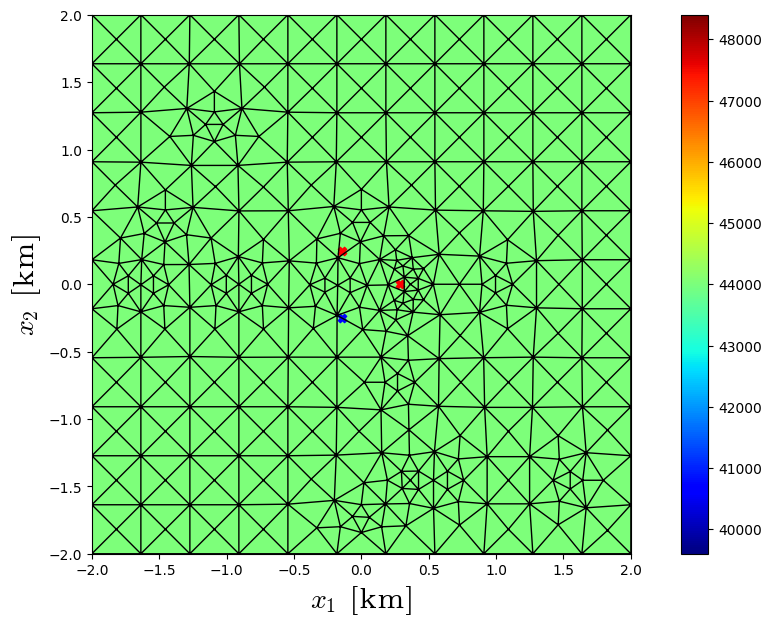

In [57]:
c_het=chy*interp_k((points[:,0], points[:,1]))
fig, ax = plt.subplots(1, 1, figsize=(13, 7))
if heterogeneities_k:
    cp1 = fem_plot(m_refined, c_het*1e6, ax=ax, shading='gouraud', colorbar=True)  
else:
    cp1 = fem_plot(m_refined, c_het*0+chy*1e6, ax=ax, shading='gouraud', colorbar=True)   
plt.scatter(WLpoints[ctrl_wells, 0], WLpoints[ctrl_wells, 1], color='r', marker="X", label='Control wells')
plt.scatter(WLpoints[sttc_wells, 0], WLpoints[sttc_wells, 1], color='b', marker="X", label='Static wells')

plt.rcParams['mathtext.fontset'] = 'cm'
ax.set_xlabel('$x_1$ [km]', size=fsize, fontname=fname)
ax.set_ylabel('$x_2$ [km]', size=fsize, fontname=fname)
ax.set_aspect('equal')
draw(m_refined,ax=ax,color="black",linewidth=lwidth-1)
# plt.grid(True)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

# plt.savefig("Images/reservoir_dis.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

## No Control

In [75]:
def output(x,C):
    return np.array([C@x])

def myexp(x):
    tol=7e2
    if x<tol:
        return np.exp(x)
    else:
        return np.exp(tol)
myexp=np.vectorize(myexp)

def myexpm1(x):
    tol=7e2
    if x<tol:
        return np.expm1(x)
    else:
        return np.expm1(tol)
myexpm1=np.vectorize(myexpm1)

def L2norm(x):
    norm = np.sqrt(dz*Ctotal@(x**2))
    return norm

def rhs_nc_h(t, x):
    N = Ad.shape[0]
    u = x[:N]
    h = x[N:2*N]
    ksi = x[2*N:]
    
    # h[h<0]=0
    # htol = 1e-1
    # h[np.abs(h) < htol] = htol
    dksi = np.zeros(C.shape[0],)
    Qc = np.array([-1.e-5, 0.])
    Qs = np.array([1.e-5])

    rhs_u = -Ad.dot(u) * tsm + (Bc.dot(Qc) + Bs.dot(Qs)) * tsm / usm
    du = solve_Md(rhs_u)

    dh = -(γ1 * usm * du + γ2 * tsm) * h + (γ2 * tsm / hsm)

    # print(np.amin(h),np.amax(dh))
    
    return np.hstack((du, dh, dksi))

In [76]:
import scipy.sparse as sp

class NonNegProjection(Projection):
    """Half-line projection on one or more state indices.

    Enforces ``y[t_idx] >= 0`` for every index in *t_idx* at each Newton
    iterate. Components outside *t_idx* are left untouched, so the projection
    composes correctly with other dynamical states occupying the rest of the
    vector.

    Parameters
    ----------
    t_idx : int or array-like of int
        Index or indices of the constrained components within the full
        state vector.  A scalar int is accepted for the single-component case.
    component_slices : list of slice, optional
        Passed through to the base ``Projection``.
    """

    def __init__(self, t_idx, component_slices=None):
        super().__init__(component_slices=component_slices)
        self.t_idx = np.atleast_1d(np.asarray(t_idx, dtype=int))

    def project(self, current_state, candidate, rhok=None, t=None, Fk_val=None):
        out = np.asarray(candidate, float).copy()
        out[self.t_idx] = np.maximum(out[self.t_idx], 0.0)
        return out

    def tangent_cone(self, candidate, current_state, rhok=None, t=None, Fk_val=None):
        n = candidate.shape[0]
        diag = np.ones(n)
        active = self.t_idx[candidate[self.t_idx] <= 0.0]
        diag[active] = 0.0
        return sp.diags(diag, format='csr')


In [83]:
# Normalization constants
tsm = 6*month
usm = 25.
hsm = tsm#1.

# Initial condition
Ns=Ad.shape[0]
Ms=C.shape[0]
y0 = np.zeros(2*Ns+Ms)
y0[Ns:2*Ns] = (Rsm/R0)/hsm

# Time span for integration
t_step = 12
tmin = 0.
tmax = tsm
t_span = [tmin/tsm, tmax/tsm]
t_eval=np.linspace(t_span[0], t_span[1], int(tmax/t_step), endpoint=True)

Ptol=1e-6/usm
htol=(Rsm/1e-6)/hsm
atol_ivp=np.ones(2*Ns+Ms)
atol_ivp[:Ns]*=Ptol
atol_ivp[Ns:2*Ns]*=htol
atol_ivp[2*Ns:]*=Ptol

u_slice = slice(0, Ns)
h_slice = slice(Ns, 2*Ns)
ksi_slice = slice(2*Ns, 2*Ns + Ms)

projection = NonNegProjection(
    t_idx=np.arange(Ns, 2*Ns),
    component_slices=[u_slice, h_slice, ksi_slice],
)
common = dict(
    method='backward_euler',
    component_slices=[u_slice, h_slice, ksi_slice],
    nl_atol=[1e-9, 1e-9, 1e-9],
    nl_rtol=[1e-6, 0.0, 1e-6],
    adaptive=True,
    atol=1e-7,
    rtol=1e-5,
    t_eval=t_eval,
)

start = time.time()
# Use adaptive BE + VI here: semismooth Newton with finite-difference Jacobians
# aborts on the first step for this 721-DOF projected system.
t_sol, y_sol, _, _, err_log = solve_nivp(
    rhs_nc_h, t_span, y0,
    projection=projection, solver='VI',
    h0=0.02, **common,
)

tsnc=t_sol*tsm
usnc=y_sol[:, u_slice].T*usm
hsnc=y_sol[:, h_slice].T*hsm
Rsnc=Rsm/hsnc
ksisnc=y_sol[:, ksi_slice].T*(usm/tsm)
yusnc=output(usnc,C).squeeze(axis=0)
yRsnc=output(Rsnc,C).squeeze(axis=0)
us_vmaxnc=np.amax(usnc)
us_vminnc=np.amin(usnc)
rs_vmaxnc=np.amax(Rsnc)
rs_vminnc=np.amin(Rsnc)
end = time.time()
time_sol=end - start
if time_sol<60:
    print("elapsed time:",round(time_sol,2),'sec')
else:
    print("elapsed time:",round(time_sol/60,2),'min')
print(f"stored time points: {len(t_sol)}")
if err_log:
    print("last solver record:", err_log[-1])


elapsed time: 1.79 min
stored time points: 365
last solver record: (0.2399775440168462, True, 0)


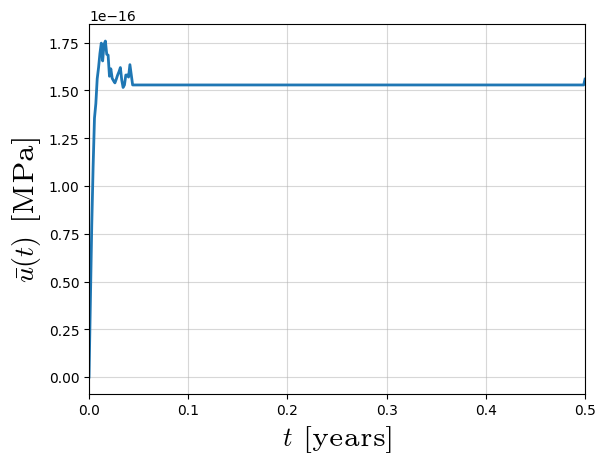

In [84]:
fig,ax=plt.subplots(1,1)
plt.plot(tsnc/year,yusnc.T,linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$\\bar{u}(t)$ [MPa]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.1e-4)
plt.grid(True, alpha=0.5)

# plt.savefig("Images/u_validation.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

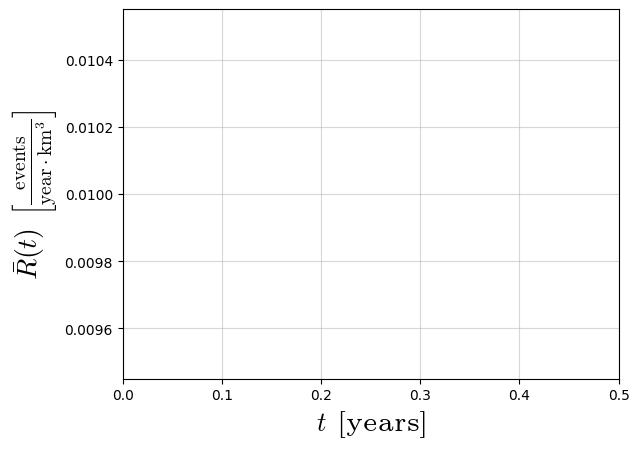

In [66]:
fig,ax=plt.subplots(1,1)
plt.plot(tsnc/year,yRsnc.T*year,linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$\\bar{R}(t)$ $\\left[\\frac{\\mathrm{events}}{\\mathrm{year} \\cdot \\mathrm{km}^3} \\right]$", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.1e-4)
plt.grid(True, alpha=0.5)

# plt.savefig("Images/R_validation.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

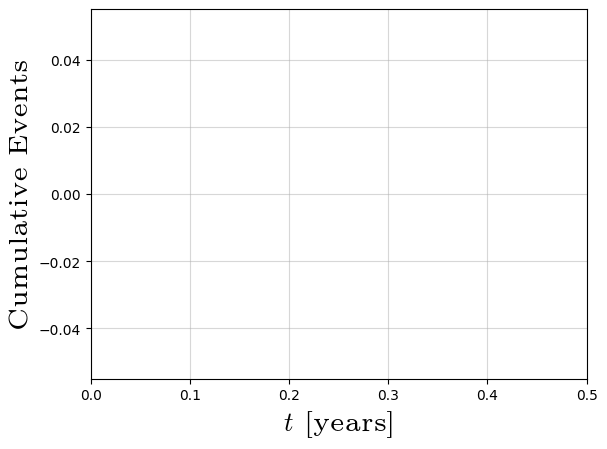

In [67]:
iyRsnc=cumulative_trapezoid((Ctotal@Rsnc),tsnc, initial=0).squeeze()

fig,ax=plt.subplots(1,1)
plt.plot(tsnc/year,iyRsnc.T,linewidth=lwidth,label='Simulated data')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("Cumulative Events", size=fsize-1, fontname=fname, color='k')
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.1e-4)
plt.grid(True, alpha=0.5)

# plt.savefig("Images/Cum_validation.pdf", format="pdf", dpi=1200, bbox_inches="tight")
plt.show()

In [68]:
@widgets.interact(ti=(1,len(tsnc)-1,1))
def show_animate(ti=len(tsnc)-1):

    fig, ax = plt.subplots(1, 2, figsize=(13, 7))

    cp0 = ax[0].tricontourf(points[:, 0], points[:, 1], triangles, usnc[:,ti], np.around(np.linspace(us_vminnc*1.0, us_vmaxnc, 22, endpoint=True),2), cmap='viridis')
    clb0 = fig.colorbar(cp0)
    clb0.set_label('[MPa]', labelpad=-35, y=1.06, rotation=0, size=15, fontname=fname)
    
    cp2 = ax[1].tricontourf(points[:, 0], points[:, 1], triangles, Rsnc[:,ti]*year, np.around(np.linspace(0., rs_vmaxnc*year*1.0, 22, endpoint=True),1), cmap='viridis')
    # cp2 = ax[1].tricontourf(points[:, 0], points[:, 1], triangles, hsnc[:,ti], cmap='viridis')
    clb1 = plt.colorbar(cp2)
    clb1.set_label('$\\left[\\frac{\\mathrm{events}}{\\mathrm{year} \\cdot \\mathrm{km}^3} \\right]$', labelpad=-35, y=1.06, rotation=0, size=15, fontname=fname)
    
    # Plot wells
    ax[0].scatter(WLpoints[ctrl_wells, 0], WLpoints[ctrl_wells, 1], color='r', marker="X", label='Control wells')
    ax[0].scatter(WLpoints[sttc_wells, 0], WLpoints[sttc_wells, 1], color='b', marker="X", label='Static wells')
    # Plot wells
    ax[1].scatter(WLpoints[ctrl_wells, 0], WLpoints[ctrl_wells, 1], color='r', marker="X", label='Control wells')
    ax[1].scatter(WLpoints[sttc_wells, 0], WLpoints[sttc_wells, 1], color='b', marker="X", label='Static wells')
    
    # Set labels, annotations, and other plot features
    plt.rcParams['mathtext.fontset'] = 'cm'
    ax[0].set_title('$u(x,t)$ on '+str(np.round(tsnc[ti]/year,2)), size=fsize-1, fontname=fname)
    ax[0].set_xlabel('$x_1$ [km]', size=fsize-2, fontname=fname)
    ax[0].set_ylabel('$x_2$ [km]', size=fsize-2, fontname=fname)
    ax[0].set_aspect('equal')
    ax[1].set_title('$R(x,t)$ on '+str(np.round(tsnc[ti]/year,2)), size=fsize-1, fontname=fname)
    ax[1].set_xlabel('$x_1$ [km]', size=fsize-2, fontname=fname)
    ax[1].set_ylabel('$x_2$ [km]', size=fsize-2, fontname=fname)
    ax[1].set_aspect('equal')
    
    # Add legend
    # ax[0].legend(prop={'family': fname, 'size': fsize-2}, fancybox=True, framealpha=0.9, borderpad=0.1, loc="upper right")
    # ax[1].legend(prop={'family': fname, 'size': fsize-2}, fancybox=True, framealpha=0.9, borderpad=0.1, loc="upper right")
    
    # Set limits
    ax[0].set_xlim(xmin, xmax)
    ax[0].set_ylim(ymin, ymax)
    ax[1].set_xlim(xmin, xmax)
    ax[1].set_ylim(ymin, ymax)

    # plt.savefig("reservoir1.pdf", format="pdf", dpi=1200, bbox_inches="tight")
    
    # Show plot
    plt.show()

ValueError: value must be between min and max (min=1, value=0, max=0)

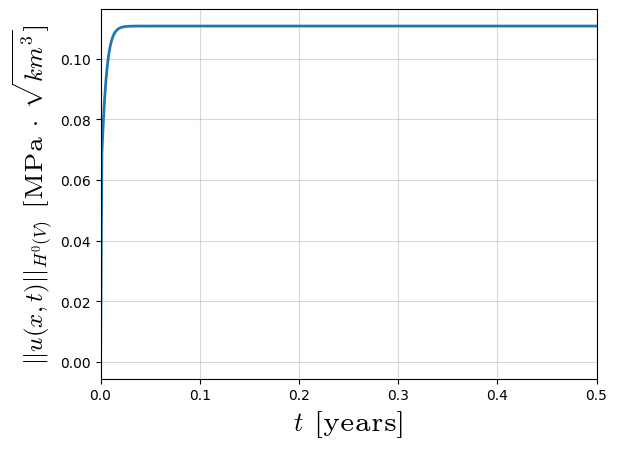

In [85]:
fig,ax=plt.subplots(1,1)
plt.plot(tsnc/year,L2norm(usnc).T,linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$||u(x,t)||_{H^0(V)}$ [MPa $\\cdot$ $\\sqrt{km^3}$]", size=fsize-2, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.1e-4)
plt.grid(True, alpha=0.5)

# plt.savefig("Images/u_norm.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

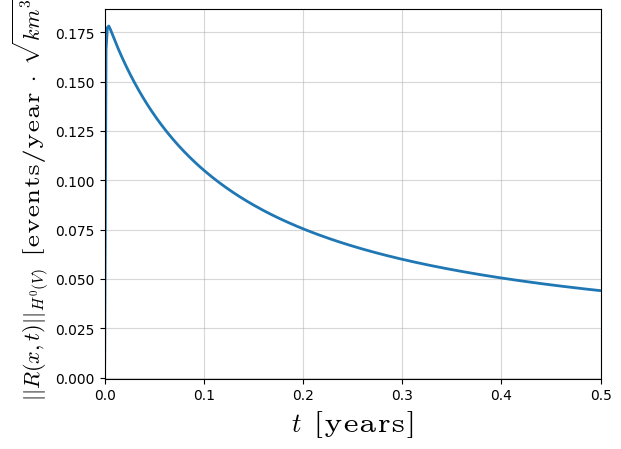

In [ ]:
fig,ax=plt.subplots(1,1)
plt.plot(tsnc/year,L2norm(Rsnc*year).T,linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$||R(x,t)||_{H^0(V)}$ [events/year $\\cdot$ $\\sqrt{km^3}$]", size=fsize-4, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.1e-4)
plt.grid(True, alpha=0.5)

# plt.savefig("Images/R_norm.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

## Control

In [ ]:
from scipy.linalg import null_space, svd
from scipy.optimize import minimize

def inv_norm_for_W(W, CB, big_penalty=1e16, svd_tol=1e-12):
    W = np.asarray(W, float)
    CB = np.atleast_2d(np.asarray(CB, float))

    Wn = null_space(W)
    if Wn.size == 0:
        return big_penalty

    M = Wn @ np.linalg.pinv(CB @ Wn)
    s = svd(M, compute_uv=False)
    return s.max()
    
def build_W_from_theta(theta, W0, mask, w_min, w_max, normalize_rows=False):
    """
    theta: 1D array of length equal to mask.sum()
    W0   : (n_r, n) binary mask (1 = participates, 0 = not)
    mask : boolean array same shape as W0, True where weights are tunable
    w_min, w_max: bounds for each nonzero weight
    normalize_rows: if True, normalize each row to unit norm (optional)
    """
    theta = np.asarray(theta, dtype=float)
    assert theta.size == mask.sum(), "theta size must match number of True in mask"

    # Map unconstrained theta -> (0,1) via sigmoid, then to [w_min, w_max]
    s = 1.0 / (1.0 + np.exp(-theta))        # (0,1)
    weights = w_min + (w_max - w_min) * s   # (w_min, w_max)

    W = np.zeros_like(W0, dtype=float)
    W[mask] = weights

    if normalize_rows:
        # Row normalization (only direction matters for nullspace)
        row_norms = np.linalg.norm(W, axis=1, keepdims=True)
        W = W / (row_norms + 1e-12)

    return W

def objective_theta(theta, CB, W0, mask, w_min, w_max, normalize_rows=False, big_penalty=1e16):
    W = build_W_from_theta(theta, W0, mask, w_min, w_max, normalize_rows=normalize_rows)
    return inv_norm_for_W(W, CB, big_penalty=big_penalty)

beta0 = 0.8
CB=(C@Bc)/beta0
iCB=np.linalg.pinv(CB)

W0 = np.ones([1,len(ctrl_wells)])

w_min, w_max = 0.8, 1.2     # user-provided bounds
mask = W0 > 0               # boolean mask

num_vars = mask.sum()
if num_vars == 0:
    raise ValueError("Mask has no tunable entries!")

# Initial guess: use W0's ones as something inside [w_min, w_max]
# e.g. map W0[mask] = 1 to the middle of the interval, then back via logit
init_weights = np.full(num_vars, (w_min + w_max) / 2.0)

# logit: p -> log(p/(1-p))
p0 = (init_weights - w_min) / (w_max - w_min)
p0 = np.clip(p0, 1e-3, 1 - 1e-3)
theta0 = np.log(p0 / (1.0 - p0))

# Run local optimization
res = minimize(
    objective_theta,
    x0=theta0,
    args=(CB, W0, mask, w_min, w_max, False),  # normalize_rows=False here
    method='Nelder-Mead',                      # or 'Powell'
    options={'maxiter': 1000, 'xatol': 1e-4, 'fatol': 1e-3}
)

theta_opt = res.x
W = build_W_from_theta(theta_opt, W0, mask, w_min, w_max, normalize_rows=False)
print("Optimal cond(CB Wn):", inv_norm_for_W(W, CB))
W = np.array([[1., 1.]])#/dz
iW=np.linalg.pinv(W)
Wn=null_space(W)
CBWn=CB@Wn
iCBWn=np.linalg.pinv(CBWn)

Optimal cond(CB Wn): 0.21375946503129445


In [ ]:
def compute_triangle_volume(mesh):
    p1 = mesh.p[:, mesh.t[0]].T  
    p2 = mesh.p[:, mesh.t[1]].T
    p3 = mesh.p[:, mesh.t[2]].T
    area = 0.5 * np.abs((p2[:, 0] - p1[:, 0]) * (p3[:, 1] - p1[:, 1]) -
                        (p3[:, 0] - p1[:, 0]) * (p2[:, 1] - p1[:, 1]))
    barycenters = (p1 + p2 + p3) / 3  # shape (N, 3) if 3D
    volume = area * dz
    return volume
mesh_vols = compute_triangle_volume(m_refined)
total_volume = np.sum(mesh_vols)

Vs = np.amin(mesh_vols)*1e3
γ10 = 1.1*np.amax(L2norm(Rsnc))*γ1/np.sqrt(Vs)/Rsm

L1=1.e-8
kw1=1.5*L1**0.5 #gain for e
ke1=1.1*L1 #gain for nu

l = -1.#.6
Tk=1.e0
Kk=2.e1
L=Tk**((1+l)/(1-l))/Kk**(l/(1-l))
Kw=L*kw1
Ke=L**2*ke1

d_ini = np.array([0.])
d_fin = np.array([-1.e-5])
top = 1*month

def mysign(x):
    eps = Ptol*usm
    f = x/(np.abs(x)+eps)
    f = np.clip(x / eps, -1.0, 1.0)
    return f

def myfunction(x,a):
    return np.power(np.absolute(x),a)*mysign(x)
myfunction=np.vectorize(myfunction,excluded=['a'])

def controller(e,ksi,t):
    switch=True
    dksi = -Ke*myfunction(e,(1+l)/(1-l))
    if switch==False:
        Q_total = iCB@(-Kw*myfunction(e,1/(1-l))+ksi)
    else:
        Q = iCBWn@(-Kw*myfunction(e,1/(1-l))+ksi)
        Q_total = Wn@Q + (iW*demand(t)).squeeze()
    return dksi,Q_total

def rhs_c_h(t, x):
    N = Ad.shape[0]
    u = x[:N]
    h = x[N:2*N]
    ksi = x[2*N:]

    # htol = 1e-6
    # h[np.abs(h)<htol] = htol
    yR=output(Rsm/(h*hsm),C).squeeze(axis=0)
    sigma=(yR-Rsm)/(γ10*Rsm)
    dksi,Qc=controller(sigma,ksi*usm/tsm,t*tsm)
    dksi *= (tsm**2 / usm)
    
    Qs = -demand(t*tsm)

    rhs_u = -Ad.dot(u) * tsm + (Bc.dot(Qc) + Bs.dot(Qs)) * tsm / usm
    du = solve_Md(rhs_u)

    dh = -(γ1 * usm * du + γ2 * tsm) * h + (γ2 * tsm / hsm)
    # dh = -(γ1 * usm * du) * h + (γ2 * tsm / hsm)
    
    return np.hstack((du, dh, dksi))
    
def y_r(t, r_ini, r_fin, top):
    s = t / top
    if t <= top:
        r = r_ini + (r_fin - r_ini) * s**3 * (10 - 15 * s + 6 * s**2)
        dr = (r_fin - r_ini) * 30 * s**2 * (1 - 2 * s + s**2) / top
    else:
        r = r_fin
        dr = 0.0
    return r, dr
    
def demand(t):
    # demand = d_fin
    demand, _ = y_r(t, d_ini, d_fin, top)
    return demand

In [ ]:
print(γ1,γ10)
# print(Kw)
# print(Ke)

9.998000399920015 215.35369843710433


In [ ]:
# Normalization constants
tsm = 6*month
usm = 2.
hsm = tsm

# Initial condition
Ns=Ad.shape[0]
Ms=C.shape[0]
y0 = np.zeros(2*Ns+Ms)
y0[Ns:2*Ns] = (Rsm/R0)/hsm

# Time span for integration
t_step = 12
tmin = 0.
tmax = tsm
t_span = [tmin/tsm, tmax/tsm]
t_eval=np.linspace(t_span[0], t_span[1], int(tmax/t_step), endpoint=True)

Ptol=1e-6/usm
htol=(Rsm/1e-6)/hsm
atol=np.ones(2*Ns+Ms)
atol[:Ns]*=Ptol
atol[Ns:2*Ns]*=htol
atol[2*Ns:]*=Kw*myfunction(Ptol,1/(1-l))

start = time.time()
sol = solve_ivp(fun=rhs_c_h, t_span=t_span, y0=y0, method='BDF', t_eval=t_eval, atol=atol)
if sol.success==False: print("Success:",sol.success)
tsc=sol.t*tsm
usc=sol.y[:Ns,:]*usm
hsc=sol.y[Ns:2*Ns,:]*hsm
ksisc=sol.y[2*Ns:,:]*(usm/tsm)
Rsc=Rsm/hsc
yusc=output(usc,C).squeeze(axis=0)
yRsc=output(Rsc,C).squeeze(axis=0)
sigmasc=(yRsc-Rsm)/(γ10*Rsm)
dksisc=np.array([controller(sigmasc[:,i],ksisc[:,i],tsc[i])[0] for i in range(len(tsc))]).T
Qcsc=np.array([controller(sigmasc[:,i],ksisc[:,i],tsc[i])[1] for i in range(len(tsc))]).T
demandsc = np.array([demand(tsc[i]) for i in range(len(tsc))]).T
us_vmaxc=np.amax(usc)
us_vminc=np.amin(usc)
rs_vmaxc=np.amax(Rsc)
rs_vminc=np.amin(Rsc)
end = time.time()
time_sol=end - start
if time_sol<60:
    print("elapsed time:",round(time_sol,2),'sec')
else:
    print("elapsed time:",round(time_sol/60,2),'min')

Success: False
elapsed time: 28.75 sec


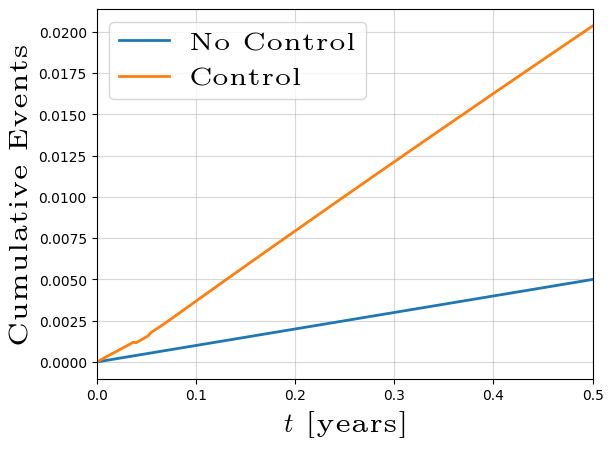

0.020353399849044128 0.005


In [ ]:
iyRsc = cumulative_trapezoid((Ctotal@Rsc),tsc, initial=0).squeeze()

fig,ax=plt.subplots(1,1)
plt.plot(tsc/year,R0*tsc,linewidth=lwidth,label='No Control')
plt.plot(tsc/year,iyRsc.T,linewidth=lwidth,label='Control')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("Cumulative Events", size=fsize-1, fontname=fname, color='k')
plt.xlim(0, tmax/year)
# plt.ylim(0, 35)
plt.grid(True, alpha=0.5)

plt.legend(prop={'family':fname, 'size':fsize-2},fancybox=True,loc="upper left")

# plt.savefig("Images/Cum_control1.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

print(iyRsc[-1],R0*tmax)

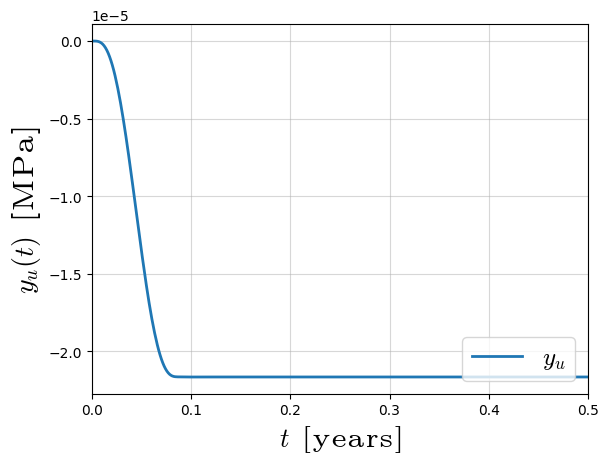

In [ ]:
fig, ax = plt.subplots(1, 1)  # First plot
plt.plot(tsc/year, yusc.T, label='$y_u$', linewidth=lwidth)

# Set plot parameters
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$y_u(t)$ [MPa]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(-14.41, -14.30)
plt.grid(True, alpha=0.5)

# Legend
plt.legend(prop={'family': fname, 'size': fsize-2}, fancybox=True, loc="lower right", ncol=2)

# axins = ax.inset_axes([0.53, 0.57, 0.35, 0.35])
# axins.plot(tsc/year, yusc.T ,linewidth=lwidth)
# axins.grid(True, alpha=0.5)
# axins.set_xlim(tmax_extraction_control/year*.4, tmax_extraction_control/year)
# axins.set_ylim(-14.3585, -14.356)
# # axins.set_xlabel("$t$ [days]", size=fsize-5, fontname=fname)
# # axins.set_yticklabels([])
# axins.set_xticklabels([])
# # axins.ticklabel_format(axis='y',scilimits=(0,0))
# ax.indicate_inset_zoom(axins)

# plt.savefig("Images/yu1.pdf", format="pdf", dpi=1200, bbox_inches="tight")

# Show the plot
plt.show()

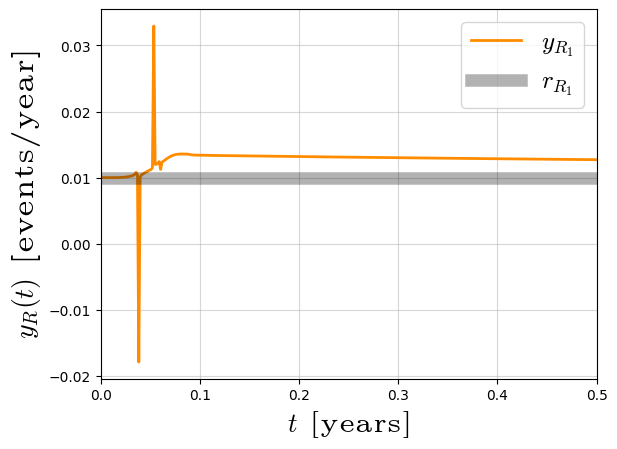

In [ ]:
fig,ax=plt.subplots(1,1)
plt.plot(tsc/year,yRsc.T*year,linewidth=lwidth,color="darkorange",label='$y_{R_1}$')
plt.plot(tsc/year,Rsm*year+0*tsc,linewidth=9,alpha=.3,color="k",label='$r_{R_1}$')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$y_R(t)$ [events/year]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0.87, 1.2)
plt.grid(True, alpha=0.5)

plt.legend(prop={'family':fname, 'size':fsize-2},fancybox=True,loc="upper right")

# plt.savefig("Images/yR1.pdf", format="pdf", dpi=1200, bbox_inches="tight")
plt.show()    

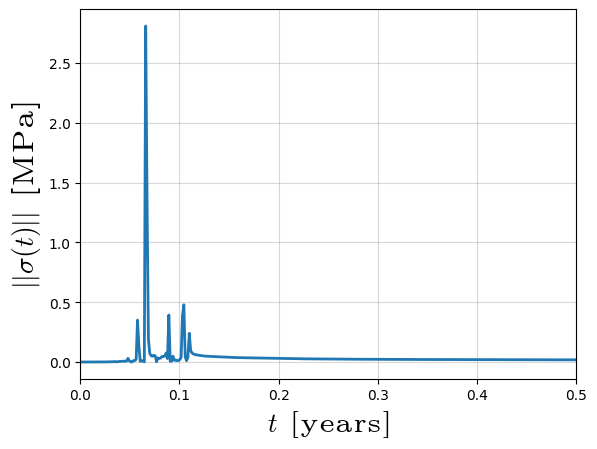

In [ ]:
fig,ax=plt.subplots(1,1)
plt.plot(tsc/year,np.sqrt(np.sum(sigmasc**2,axis=0)),linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize-1, fontname=fname)
plt.ylabel("$||\\sigma(t)||$ [MPa]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.5e-2)
plt.grid(True, alpha=0.5)
ax.ticklabel_format(axis='y',scilimits=(0,0))

# axins = ax.inset_axes([0.3, 0.53, 0.4, 0.4])
# axins.plot(tsc/day,np.sqrt(np.sum(sigmasc**2,axis=0)) ,linewidth=lwidth)
# axins.grid(True, alpha=0.5)
# axins.set_xlim(tmax_extraction_control/year*.8, tmax_extraction_control/year)
# axins.set_ylim(0, .5e-3)
# axins.set_xlabel("$t$ [days]", size=fsize-5, fontname=fname)
# axins.ticklabel_format(axis='y',scilimits=(0,0))
# ax.indicate_inset_zoom(axins)

# plt.savefig("Images/y_norm1.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

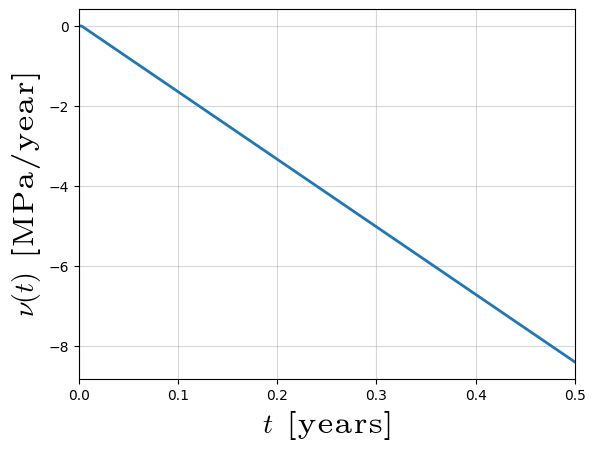

In [ ]:
fig,ax=plt.subplots(1,1)
plt.plot(tsc/year,ksisc.T*year,linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize, fontname=fname)
plt.ylabel("$\\nu(t)$ [MPa/year]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(0, 1.1e-4)
plt.grid(True, alpha=0.5)

# plt.savefig("Images/nu1.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

In [ ]:
from matplotlib.ticker import MaxNLocator
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

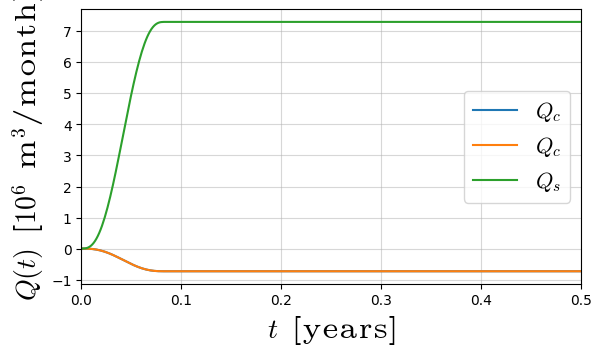

In [ ]:
fig,ax=plt.subplots(1,1)
plt.plot(tsc/year,(Qcsc.T)*1e9*month/1e6,label="$Q_c$",linewidth=lwidth-0.5)
plt.plot(tsc/year,(-demandsc.T)*1e9*month/1e6,label="$Q_s$",linewidth=lwidth-0.5)
# Qss=np.array([Qs for t in ts]).T
# plt.plot(ts/year,Qss.T*1e9,label="Qs",linewidth=lwidth)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize, fontname=fname)
plt.ylabel("$Q(t)$ [$10^6$ m$^3$/month]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(-12, 12)
# plt.legend()
plt.grid(True, alpha=0.5)

plt.legend(prop={'family':fname, 'size':fsize-4},fancybox=True,loc="center right")

set_size(5,24*4/35)

# plt.savefig("Images/Q1.pdf", format="pdf", dpi=1200, bbox_inches="tight")
plt.show()

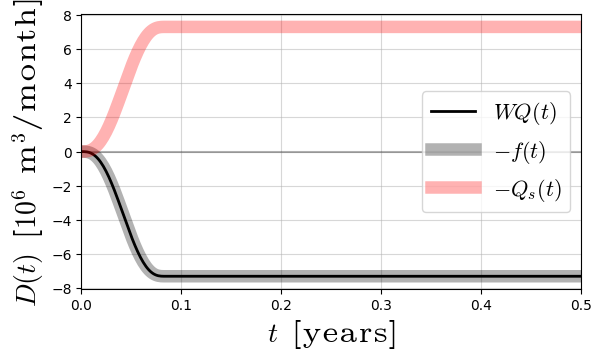

In [ ]:
fig,ax=plt.subplots(1,1)
plt.plot(tsc/year,tsc*0,color="k",alpha=.3)
plt.plot(tsc/year,1e9*(W@(Qcsc.T).T).T*month/1e6,"k",label=r"$W Q(t)$",linewidth=lwidth)
plt.plot(tsc/year,1e9*demandsc.T*month/1e6,"k",label="$-f(t)$",linewidth=9,alpha=.3)
plt.plot(tsc/year,-1e9*demandsc.T*month/1e6,"r",label="$-Q_s(t)$",linewidth=9,alpha=.3)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.xlabel("$t$ [years]", size=fsize, fontname=fname)
plt.ylabel("$D(t)$ [$10^6$ m$^3$/month]", size=fsize, fontname=fname)
plt.xlim(0, tmax/year)
# plt.ylim(-12, 12)
plt.grid(True, alpha=0.5)

set_size(5,24*4/35)

plt.legend(prop={'family':fname, 'size':fsize-4},fancybox=True,loc="center right")
# plt.savefig("Images/D1.pdf", format="pdf", dpi=1200, bbox_inches="tight")

plt.show()

In [ ]:
@widgets.interact(ti=(0,len(tsc)-1,1))
def show_animate(ti=len(tsc)-1):

    fig, ax = plt.subplots(1, 2, figsize=(13, 7))

    cp1 = ax[0].tricontourf(points[:, 0], points[:, 1], triangles, usc[:,ti], np.around(np.linspace(us_vminc, us_vmaxc, 22, endpoint=True),2), cmap='viridis')
    clb0 = fig.colorbar(cp1)
    clb0.set_label('[MPa]', labelpad=-35, y=1.06, rotation=0, size=15, fontname=fname)
    
    cp2 = ax[1].tricontourf(points[:, 0], points[:, 1], triangles, Rsc[:,ti]*year, np.around(np.linspace(0., rs_vmaxc*year*.6, 22, endpoint=True),2), cmap='viridis')
    clb1 = plt.colorbar(cp2)
    clb1.set_label('[events/year]', labelpad=-35, y=1.06, rotation=0, size=15, fontname=fname)
  
    # Plot wells
    ax[0].scatter(WLpoints[ctrl_wells, 0], WLpoints[ctrl_wells, 1], color='r', marker="X", label='Control wells')
    ax[0].scatter(WLpoints[sttc_wells, 0], WLpoints[sttc_wells, 1], color='r', marker="X", label='Static wells')
    # Plot wells
    ax[1].scatter(WLpoints[ctrl_wells, 0], WLpoints[ctrl_wells, 1], color='r', marker="X", label='Control wells')
    ax[1].scatter(WLpoints[sttc_wells, 0], WLpoints[sttc_wells, 1], color='r', marker="X", label='Static wells')
    
    # Set labels, annotations, and other plot features
    plt.rcParams['mathtext.fontset'] = 'cm'
    ax[0].set_title('$u(x,t)$ on '+str(np.round(tsc[ti]/year,2)), size=fsize-1, fontname=fname)
    ax[0].set_xlabel('$x_1$ [km]', size=fsize-2, fontname=fname)
    ax[0].set_ylabel('$x_2$ [km]', size=fsize-2, fontname=fname)
    ax[0].set_aspect('equal')
    ax[1].set_title('$R(x,t)$ on '+str(np.round(tsc[ti]/year,2)), size=fsize-1, fontname=fname)
    ax[1].set_xlabel('$x_1$ [km]', size=fsize-2, fontname=fname)
    ax[1].set_ylabel('$x_2$ [km]', size=fsize-2, fontname=fname)
    ax[1].set_aspect('equal')
    
    # Add legend
    # ax[0].legend(prop={'family': fname, 'size': fsize-2}, fancybox=True, framealpha=0.9, borderpad=0.1, loc="upper right")
    # ax[1].legend(prop={'family': fname, 'size': fsize-2}, fancybox=True, framealpha=0.9, borderpad=0.1, loc="upper right")
    
    # Set limits
    ax[0].set_xlim(xmin, xmax)
    ax[0].set_ylim(ymin, ymax)
    ax[1].set_xlim(xmin, xmax)
    ax[1].set_ylim(ymin, ymax)

    # plt.savefig("reservoir1.pdf", format="pdf", dpi=1200, bbox_inches="tight")
    
    # Show plot
    plt.show()

interactive(children=(IntSlider(value=364, description='ti', max=364), Output()), _dom_classes=('widget-intera…

In [1]:
def build_rhs_nc_h_jac():
    """Build an analytic Jacobian for the no-control rhs.

    This is cheap enough for short experiments, but a full adaptive benchmark
    with semismooth Newton is still much heavier than the VI path because each
    implicit stage solves a 721-state projected system.
    """
    Ad_dense = Ad.toarray() if sp.issparse(Ad) else np.asarray(Ad, dtype=float)
    Ju = np.column_stack(
        [np.asarray(solve_Md((-tsm * Ad_dense)[:, j]), dtype=float).ravel() for j in range(Ad_dense.shape[1])]
    )
    source_u = (Bc.dot(np.array([-1.0e-5, 0.0])) + Bs.dot(np.array([1.0e-5]))) * tsm / usm
    du_offset = np.asarray(solve_Md(np.asarray(source_u, dtype=float).ravel()), dtype=float).ravel()

    def rhs_nc_h_jac(t, x):
        N = Ad.shape[0]
        u = x[:N]
        h = x[N:2*N]

        du = Ju @ u + du_offset
        du = np.asarray(du, dtype=float).ravel()

        J_hu = -γ1 * usm * (h[:, None] * Ju)
        J_hh = np.diag(-(γ1 * usm * du + γ2 * tsm))

        J = np.zeros((2 * N + Ms, 2 * N + Ms), dtype=float)
        J[:N, :N] = Ju
        J[N:2*N, :N] = J_hu
        J[N:2*N, N:2*N] = J_hh
        return J

    return rhs_nc_h_jac


def recommended_no_control_vi_options():
    return dict(
        method='backward_euler',
        solver='VI',
        adaptive=True,
        atol=1e-7,
        rtol=1e-5,
        t_eval=t_eval,
        h0=0.02,
    )


def recommended_no_control_ssn_options():
    return dict(
        method='backward_euler',
        solver='semismooth_newton',
        solver_opts={
            'rhs_jac': build_rhs_nc_h_jac(),
            'jacobian_scaling': 'row',
        },
        adaptive=True,
        atol=1e-7,
        rtol=1e-5,
        t_eval=t_eval,
        h0=0.02,
    )


def short_projected_probe(opts, horizon=0.05):
    """Run a short-horizon solver probe before attempting a full-year solve."""
    probe_span = [t_span[0], min(t_span[0] + horizon, t_span[1])]
    tic = time.time()
    t_try, y_try, h_try, fk_try, err_try = solve_nivp(
        rhs_nc_h,
        probe_span,
        y0,
        projection=projection,
        component_slices=[u_slice, h_slice, ksi_slice],
        nl_atol=[1e-9, 1e-9, 1e-9],
        nl_rtol=[1e-6, 0.0, 1e-6],
        **opts,
    )
    wall = time.time() - tic
    print(f'wall: {wall:.2f} sec')
    print(f'stored points: {len(t_try)}')
    print(f'final time: {t_try[-1]:.4f}')
    if err_try:
        print(f'last solver record: {err_try[-1]}')
    print(f'all finite: {np.isfinite(y_try).all()}')
    return t_try, y_try, h_try, fk_try, err_try


print('Helper cell loaded.')
print('Use recommended_no_control_vi_options() for the practical notebook default.')
print('Use recommended_no_control_ssn_options() only after a short_projected_probe(...).')


Helper cell loaded.
Use recommended_no_control_vi_options() for the practical notebook default.
Use recommended_no_control_ssn_options() only after a short_projected_probe(...).
